In [16]:
import random
import heapq
import copy
import csv
import statistics
from collections import defaultdict, Counter
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

In [20]:
TV, FRIEND, EXPERT, INFLUENCER = 1, 2, 3, 4
ROLE_NAMES = {
    TV: "Smi",
    FRIEND: "Friend",
    EXPERT: "Expert",
    INFLUENCER: "Influencer",
}

CFG = {
    "n": 400,
    "N_ref": 1500,

    "k_list": [10, 15, 20],

    "candidate_M": 100,

    "mc_greedy": 30,
    "mc_final": 120,

    "tim_rr_sets": 1000,

    "num_graphs": 20,
    "random_sets_per_graph": 5,

    "plot_results": True,
    "csv_filename": "multi_graph_results.csv",

    "verbose": False,

    "seed_graph": 2026,
    "seed_mc": 777,

    "tv_can_be_activated_by": {TV, EXPERT},

    "w_range": (0.8, 1.13),

    "role_counts": {TV: 18, INFLUENCER: 50, EXPERT: 60},

    "out_deg_real": {
        FRIEND: (45, 85),
        EXPERT: (180, 240),
        INFLUENCER: (170, 230),
        TV: (200, 370),
    },

    "min_floor_model": {
        FRIEND: 16,
        EXPERT: 60,
        INFLUENCER: 58,
        TV: 82,
    },

    "trust": {
        "news":     {TV: 0.30, FRIEND: 0.08, EXPERT: 0.12, INFLUENCER: 0.045},
        "medicine": {TV: 0.16, FRIEND: 0.30, EXPERT: 0.26, INFLUENCER: 0.05},
        "add":      {TV: 0.24, FRIEND: 0.30, EXPERT: 0.26, INFLUENCER: 0.05},
    },

    "beta_by_type": {
        "news": 0.27,
        "medicine": 0.17,
        "add": 0.17,
    },

    "info_types": ("news", "medicine", "add"),
}


In [3]:

# graph


def scale_range(lo_hi_real, n, n_ref, min_floor):
    lo, hi = lo_hi_real
    factor = (n - 1) / (n_ref - 1)
    lo_s = max(min_floor, int(round(lo * factor)))
    hi_s = max(lo_s, int(round(hi * factor)))
    hi_s = min(hi_s, n - 1)
    return lo_s, hi_s


def assign_roles(G, role_counts, rng):
    nodes = list(G.nodes())
    rng.shuffle(nodes)

    role_of = {}
    idx = 0
    for role, cnt in role_counts.items():
        for u in nodes[idx:idx + cnt]:
            role_of[u] = role
        idx += cnt

    for u in nodes[idx:]:
        role_of[u] = FRIEND

    nx.set_node_attributes(G, role_of, "role")


def build_graph(cfg):
    rng = random.Random(cfg["seed_graph"])
    n = cfg["n"]

    G = nx.DiGraph()
    G.add_nodes_from(range(n))

    assign_roles(G, cfg["role_counts"], rng)

    nodes = list(G.nodes())
    for u in nodes:
        r = G.nodes[u]["role"]
        lo, hi = scale_range(
            cfg["out_deg_real"][r],
            n,
            cfg["N_ref"],
            cfg["min_floor_model"][r]
        )
        d = rng.randint(lo, hi)
        targets = rng.sample([v for v in nodes if v != u], d)
        for v in targets:
            G.add_edge(u, v)

    w_lo, w_hi = cfg["w_range"]
    for u, v in G.edges():
        G[u][v]["w"] = rng.uniform(w_lo, w_hi)

    return G








In [4]:

# cascade


def edge_prob(G, u, v, info_type, cfg):
    u_role = G.nodes[u]["role"]
    v_role = G.nodes[v]["role"]

    if v_role == TV and u_role not in cfg["tv_can_be_activated_by"]:
        return 0.0

    trust = cfg["trust"][info_type][u_role]
    beta = cfg["beta_by_type"][info_type]
    w = G[u][v]["w"]

    p = beta * trust * w
    return min(1.0, max(0.0, p))


def ic(G, seeds, info_type, cfg, rng):
    active = set(seeds)
    activated = set(seeds)
    layers = []

    while active:
        new_active = set()

        for u in active:
            for v in G.successors(u):
                if v in activated:
                    continue
                p = edge_prob(G, u, v, info_type, cfg)
                if rng.random() < p:
                    new_active.add(v)
                    activated.add(v)

        if new_active:
            layers.append(len(new_active))

        active = new_active

    return activated, layers


def estimate_spread(G, seeds, info_type, cfg, mc, base_seed):
    total = 0
    for i in range(mc):
        rng = random.Random(base_seed + i)
        activated, _ = ic(G, seeds, info_type, cfg, rng)
        total += len(activated)
    return total / mc



In [5]:

# random


def random_baseline(G, info_type, k, cfg):
    rng = random.Random(cfg["seed_mc"] + 9999)
    spreads = []
    role_sum = Counter()

    for i in range(cfg["random_sets_per_graph"]):
        seeds = rng.sample(list(G.nodes()), k)
        spread = estimate_spread(
            G, seeds, info_type, cfg,
            mc=cfg["mc_greedy"],
            base_seed=cfg["seed_mc"] + 100000 + i
        )
        spreads.append(spread)

        roles = Counter(ROLE_NAMES[G.nodes[u]["role"]] for u in seeds)
        role_sum.update(roles)

    avg_roles = {}
    for role in ["Tv", "Friend", "Expert", "Influencer"]:
        avg_roles[role] = role_sum[role] / cfg["random_sets_per_graph"]

    return {
        "mean": sum(spreads) / len(spreads),
        "min": min(spreads),
        "max": max(spreads),
        "roles": avg_roles,
    }



In [6]:

# CELF


def build_candidates(G, cfg):
    topM = [u for u, _ in sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:cfg["candidate_M"]]]
    important = [u for u in G.nodes() if G.nodes[u]["role"] in (TV, EXPERT, INFLUENCER)]
    return list(dict.fromkeys(important + topM))


def celf_select(G, info_type, k, cfg):
    candidates = build_candidates(G, cfg)
    mc = cfg["mc_greedy"]
    base_seed = cfg["seed_mc"]

    chosen = []
    base = estimate_spread(G, chosen, info_type, cfg, mc, base_seed)

    heap = []
    for v in candidates:
        spread_v = estimate_spread(G, [v], info_type, cfg, mc, base_seed)
        gain = spread_v - base
        heapq.heappush(heap, (-gain, v, 0))

    used = set()

    while len(chosen) < k and heap:
        neg_gain, v, last = heapq.heappop(heap)
        if v in used:
            continue

        if last == len(chosen):
            chosen.append(v)
            used.add(v)
            base = estimate_spread(G, chosen, info_type, cfg, mc, base_seed)
        else:
            spread_sv = estimate_spread(G, chosen + [v], info_type, cfg, mc, base_seed)
            gain = spread_sv - base
            heapq.heappush(heap, (-gain, v, len(chosen)))

    return chosen





In [7]:

# TIM-like


def build_reverse_graph(G, info_type, cfg):
    GR = nx.DiGraph()
    GR.add_nodes_from(G.nodes())

    for u, v in G.edges():
        p = edge_prob(G, u, v, info_type, cfg)
        if p > 0:
            GR.add_edge(v, u, p=p)

    return GR


def make_rr_set(GR, rng):
    start = rng.choice(list(GR.nodes()))
    rr = {start}
    stack = [start]

    while stack:
        cur = stack.pop()
        for nxt in GR.successors(cur):
            if nxt in rr:
                continue
            if rng.random() < GR[cur][nxt]["p"]:
                rr.add(nxt)
                stack.append(nxt)

    return rr


def tim_select(G, info_type, k, cfg):
    GR = build_reverse_graph(G, info_type, cfg)
    rng = random.Random(cfg["seed_mc"] + 300000)

    rr_sets = []
    for _ in range(cfg["tim_rr_sets"]):
        rr_sets.append(make_rr_set(GR, rng))

    node_to_rr = defaultdict(set)
    for i, rr in enumerate(rr_sets):
        for u in rr:
            node_to_rr[u].add(i)

    covered = set()
    seeds = []

    for _ in range(k):
        best_node = None
        best_gain = -1

        for u in G.nodes():
            if u in seeds:
                continue

            gain = 0
            for rr_id in node_to_rr[u]:
                if rr_id not in covered:
                    gain += 1

            if gain > best_gain:
                best_gain = gain
                best_node = u

        if best_node is None:
            break

        seeds.append(best_node)
        for rr_id in node_to_rr[best_node]:
            covered.add(rr_id)

    return seeds


In [8]:

# helpers


def seed_roles(G, seeds):
    return dict(Counter(ROLE_NAMES[G.nodes[u]["role"]] for u in seeds))


def role_degree_stats(G):
    by_role = defaultdict(list)
    for u in G.nodes():
        by_role[G.nodes[u]["role"]].append(G.out_degree(u))

    print("\nOut-degree stats by role:")
    for r in sorted(by_role):
        degs = sorted(by_role[r])
        mean = sum(degs) / len(degs)
        print(
            f"  role {r} ({ROLE_NAMES[r]}): count={len(degs)} "
            f"min={degs[0]} median={degs[len(degs)//2]} mean={mean:.1f} max={degs[-1]}"
        )



# one graph


def run_one_graph(cfg, graph_seed):
    local_cfg = copy.deepcopy(cfg)
    local_cfg["seed_graph"] = graph_seed

    G = build_graph(local_cfg)

    result = {}

    for info_type in local_cfg["info_types"]:
        result[info_type] = {}

        for k in local_cfg["k_list"]:
            random_res = random_baseline(G, info_type, k, local_cfg)

            celf_seeds = celf_select(G, info_type, k, local_cfg)
            celf_spread = estimate_spread(
                G, celf_seeds, info_type, local_cfg,
                mc=local_cfg["mc_final"],
                base_seed=local_cfg["seed_mc"] + 500000
            )

            tim_seeds = tim_select(G, info_type, k, local_cfg)
            tim_spread = estimate_spread(
                G, tim_seeds, info_type, local_cfg,
                mc=local_cfg["mc_final"],
                base_seed=local_cfg["seed_mc"] + 700000
            )

            result[info_type][k] = {
                "random_mean": random_res["mean"],
                "random_min": random_res["min"],
                "random_max": random_res["max"],
                "random_roles": random_res["roles"],

                "celf_mean": celf_spread,
                "celf_roles": seed_roles(G, celf_seeds),

                "tim_mean": tim_spread,
                "tim_roles": seed_roles(G, tim_seeds),

                "celf_ratio": celf_spread / random_res["mean"] if random_res["mean"] > 0 else None,
                "tim_ratio": tim_spread / random_res["mean"] if random_res["mean"] > 0 else None,
            }

    return result



# many graphs


def run_all_graphs(cfg):
    all_results = {info_type: {k: [] for k in cfg["k_list"]} for info_type in cfg["info_types"]}

    for i in range(cfg["num_graphs"]):
        graph_seed = cfg["seed_graph"] + i
        print(f"\n====== graph {i+1}/{cfg['num_graphs']} | seed_graph={graph_seed} ======")

        one = run_one_graph(cfg, graph_seed)

        for info_type in cfg["info_types"]:
            for k in cfg["k_list"]:
                row = {"graph_seed": graph_seed}
                row.update(one[info_type][k])
                all_results[info_type][k].append(row)

                print(
                    f"{info_type}, k={k}: "
                    f"Random={row['random_mean']:.2f}, "
                    f"CELF={row['celf_mean']:.2f}, "
                    f"TIM={row['tim_mean']:.2f}"
                )

    return all_results


In [18]:
def show_summary_table(all_results, cfg):
    rows = []

    for info_type in cfg["info_types"]:
        for k in cfg["k_list"]:
            data = all_results[info_type][k]

            random_vals = [x["random_mean"] for x in data]
            celf_vals = [x["celf_mean"] for x in data]
            tim_vals = [x["tim_mean"] for x in data]

            celf_ratios = [x["celf_ratio"] for x in data if x["celf_ratio"] is not None]
            tim_ratios = [x["tim_ratio"] for x in data if x["tim_ratio"] is not None]

            rows.append({
                "info_type": info_type,
                "k": k,
                "Random": round(statistics.mean(random_vals), 2),
                "CELF": round(statistics.mean(celf_vals), 2),
                "TIM": round(statistics.mean(tim_vals), 2),
                "CELF/Random": round(statistics.mean(celf_ratios), 3),
                "TIM/Random": round(statistics.mean(tim_ratios), 3),
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["info_type", "k"]).reset_index(drop=True)

    def color_by_type(df, cols, cmap_name):
        styles = pd.DataFrame("", index=df.index, columns=df.columns)
        cmap = cm.get_cmap(cmap_name)

        for t in df["info_type"].unique():
            part = df[df["info_type"] == t]
            vals = part[cols].values.flatten()

            mn = vals.min()
            mx = vals.max()

            for i in part.index:
                for col in cols:
                    x = df.loc[i, col]

                    if mx == mn:
                        level = 0.5
                    else:
                        level = (x - mn) / (mx - mn)

                    # делаем цвета светлее, чтобы текст был читаемым
                    level = 0.15 + 0.45 * level

                    color = mcolors.to_hex(cmap(level))
                    styles.loc[i, col] = f"background-color: {color}; color: black"

        return styles

    styled = (
        df.style
        .apply(color_by_type, axis=None, cols=["Random", "CELF", "TIM"], cmap_name="Blues")
        .apply(color_by_type, axis=None, cols=["CELF/Random", "TIM/Random"], cmap_name="Greens")
        .set_properties(**{"text-align": "center"})
        .set_caption("Summary over all graphs")
    )

    display(styled)
    return df

In [12]:

# plots


def plot_spread_vs_k(all_results, cfg):
    for info_type in cfg["info_types"]:
        plt.figure(figsize=(7, 5))

        random_means = []
        celf_means = []
        tim_means = []

        for k in cfg["k_list"]:
            rows = all_results[info_type][k]

            random_vals = [r["random_mean"] for r in rows]
            celf_vals = [r["celf_mean"] for r in rows]
            tim_vals = [r["tim_mean"] for r in rows]

            random_means.append(statistics.mean(random_vals))
            celf_means.append(statistics.mean(celf_vals))
            tim_means.append(statistics.mean(tim_vals))

        plt.plot(cfg["k_list"], random_means, marker="o", label="Random")
        plt.plot(cfg["k_list"], celf_means, marker="o", label="CELF")
        plt.plot(cfg["k_list"], tim_means, marker="o", label="TIM")

        plt.xlabel("k - число начальных распространителей")
        plt.ylabel("Среднее число активированных вершин")
        plt.title(f"{info_type}: Среднее число активированных вершин для разных k")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.show()


def plot_role_bars(all_results, cfg):
    role_order = ["Smi", "Friend", "Expert", "Influencer"]

    for info_type in cfg["info_types"]:
        fig, axes = plt.subplots(1, len(cfg["k_list"]), figsize=(6 * len(cfg["k_list"]), 5), squeeze=False)

        for j, k in enumerate(cfg["k_list"]):
            rows = all_results[info_type][k]

            random_avg = []
            celf_avg = []
            tim_avg = []

            for role in role_order:
                random_vals = [r["random_roles"].get(role, 0) for r in rows]
                celf_vals = [r["celf_roles"].get(role, 0) for r in rows]
                tim_vals = [r["tim_roles"].get(role, 0) for r in rows]

                random_avg.append(sum(random_vals) / len(random_vals))
                celf_avg.append(sum(celf_vals) / len(celf_vals))
                tim_avg.append(sum(tim_vals) / len(tim_vals))

            ax = axes[0][j]
            x = range(len(role_order))
            width = 0.25

            ax.bar([i - width for i in x], random_avg, width=width, label="Random")
            ax.bar([i for i in x], celf_avg, width=width, label="CELF")
            ax.bar([i + width for i in x], tim_avg, width=width, label="TIM")

            ax.set_xticks(list(x))
            ax.set_xticklabels(role_order)
            ax.set_title(f"{info_type}, k={k}")
            ax.set_ylabel("Среднее число выбранных ролей")
            ax.legend()

        plt.tight_layout()
        plt.show()


def plot_ratio_lines(all_results, cfg):
    for info_type in cfg["info_types"]:
        plt.figure(figsize=(7, 5))

        celf_means = []
        tim_means = []

        for k in cfg["k_list"]:
            rows = all_results[info_type][k]
            celf_ratios = [r["celf_ratio"] for r in rows if r["celf_ratio"] is not None]
            tim_ratios = [r["tim_ratio"] for r in rows if r["tim_ratio"] is not None]

            celf_means.append(statistics.mean(celf_ratios))
            tim_means.append(statistics.mean(tim_ratios))

        plt.plot(cfg["k_list"], celf_means, marker="o", label="CELF / Random")
        plt.plot(cfg["k_list"], tim_means, marker="o", label="TIM / Random")
        plt.grid(True, alpha=0.25)
        plt.xlabel("k - число начальных распространителей")
        plt.ylabel("Среднее значение отношения")
        plt.title(f"{info_type}: Среднее значение отношения algorithm/random")
        plt.legend()
        plt.show()



Out-degree stats by role:
  role 1 (Smi): count=18 min=82 median=87 mean=88.6 max=97
  role 2 (Friend): count=272 min=16 median=20 mean=19.6 max=23
  role 3 (Expert): count=60 min=60 median=62 mean=61.7 max=64
  role 4 (Influencer): count=50 min=58 median=59 mean=59.3 max=61

====== graph 1/20 | seed_graph=2026 ======
news, k=10: Random=48.83, CELF=147.68, TIM=151.72
news, k=15: Random=61.76, CELF=176.48, TIM=173.10
news, k=20: Random=80.61, CELF=183.61, TIM=186.19
medicine, k=10: Random=110.65, CELF=151.21, TIM=162.04
medicine, k=15: Random=129.06, CELF=174.61, TIM=178.73
medicine, k=20: Random=152.01, CELF=190.27, TIM=191.53
add, k=10: Random=123.77, CELF=163.27, TIM=184.18
add, k=15: Random=137.37, CELF=183.82, TIM=195.45
add, k=20: Random=158.99, CELF=197.43, TIM=210.29

====== graph 2/20 | seed_graph=2027 ======
news, k=10: Random=37.30, CELF=147.12, TIM=152.43
news, k=15: Random=58.69, CELF=177.11, TIM=179.86
news, k=20: Random=74.77, CELF=188.21, TIM=186.22
medicine, k=10: Rand

/tmp/ipykernel_15147/2898111818.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_15147/2898111818.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


,info_type,k,Random,CELF,TIM,CELF/Random,TIM/Random
0,add,10,118.030000,172.850000,184.260000,1.468000,1.565000
1,add,15,141.070000,192.060000,200.340000,1.363000,1.422000
2,add,20,157.710000,204.450000,211.960000,1.297000,1.345000
3,medicine,10,109.600000,153.940000,159.220000,1.408000,1.456000
4,medicine,15,132.360000,174.280000,178.420000,1.318000,1.349000
5,medicine,20,149.640000,190.290000,190.920000,1.272000,1.276000
6,news,10,43.590000,144.100000,154.070000,3.359000,3.593000
7,news,15,61.330000,165.710000,181.830000,2.725000,2.986000
8,news,20,78.220000,178.760000,192.160000,2.296000,2.467000


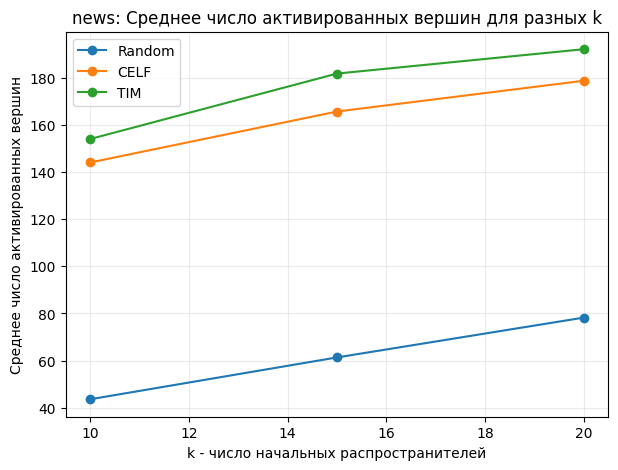

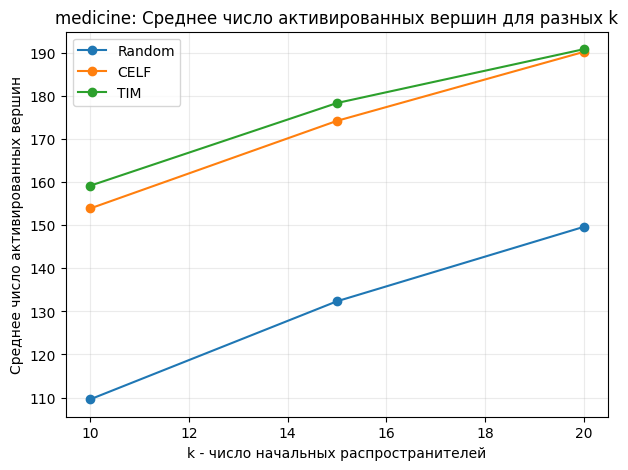

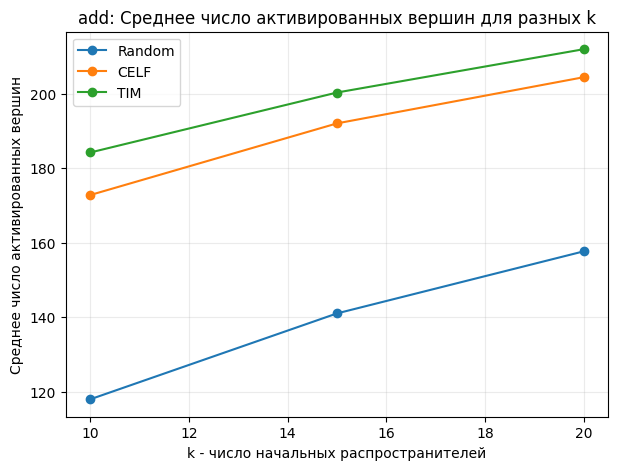

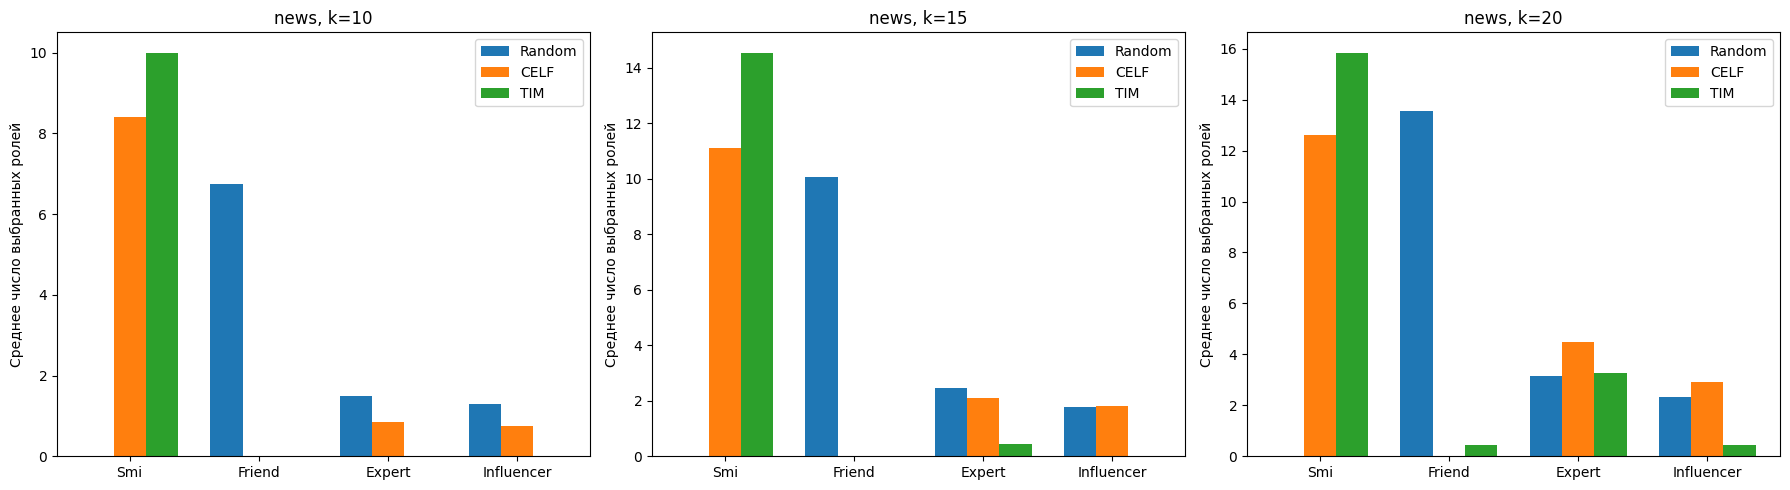

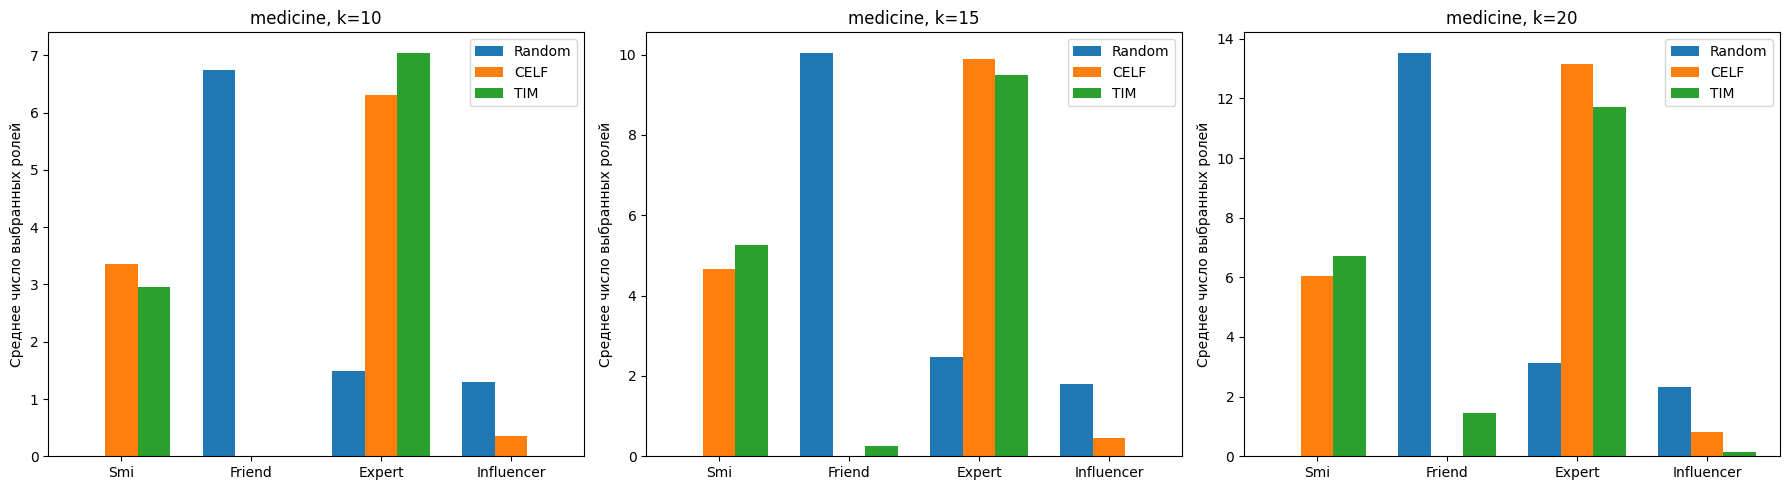

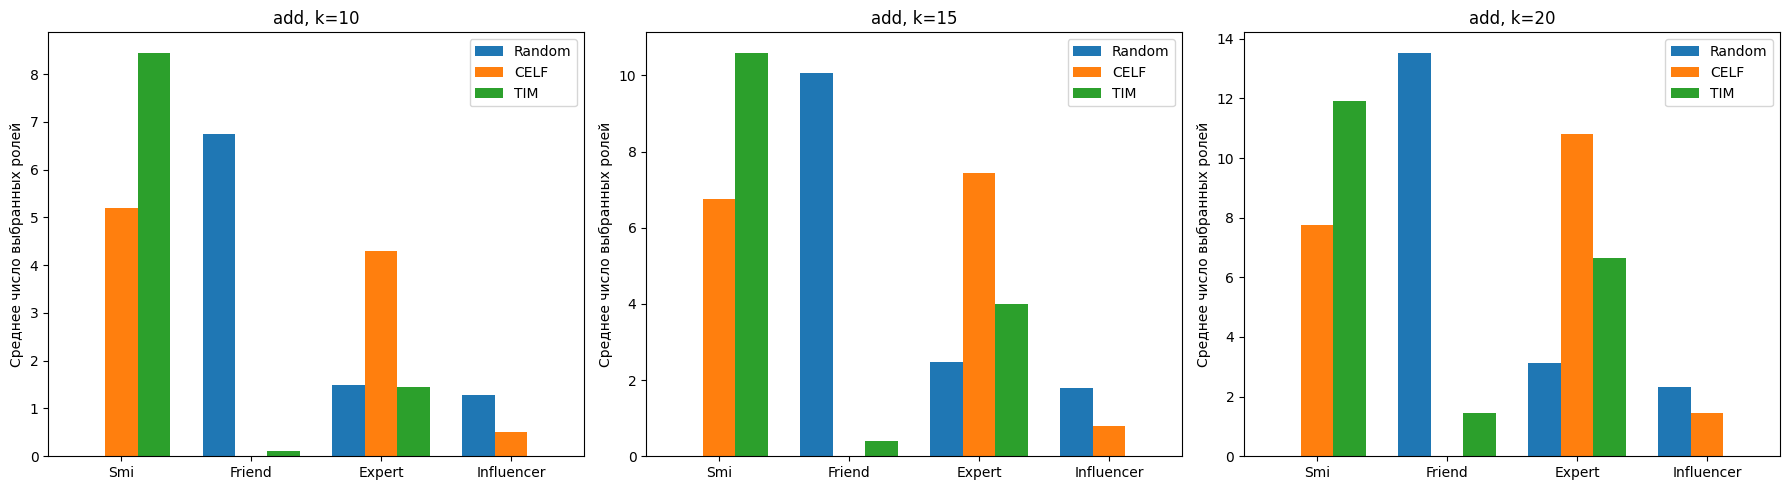

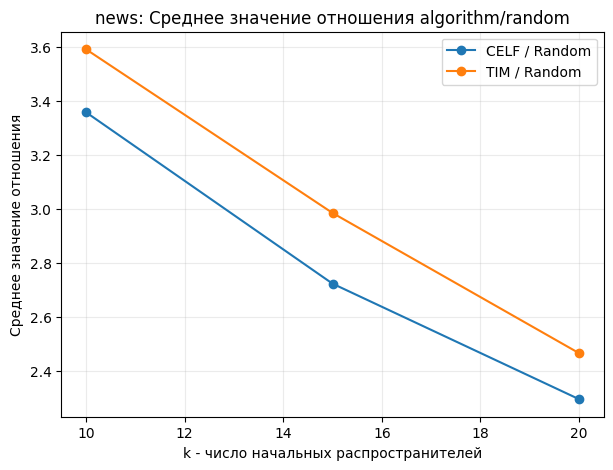

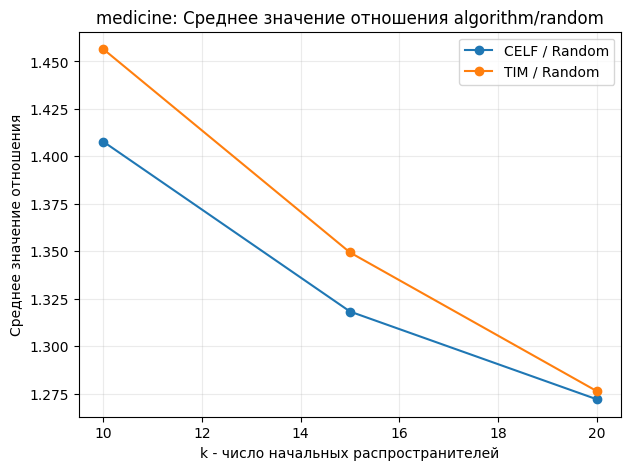

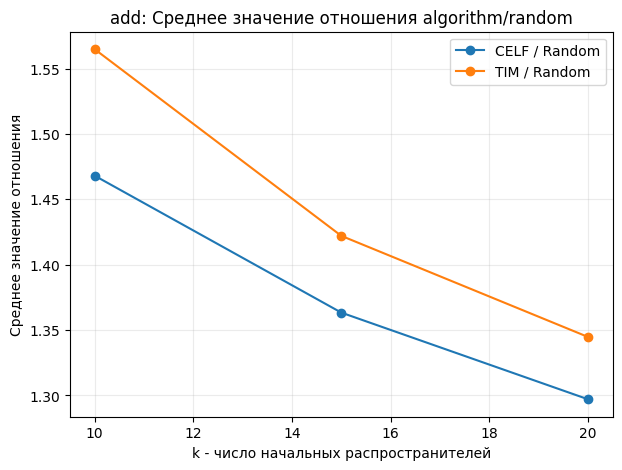

In [21]:

# main


if __name__ == "__main__":
    G = build_graph(CFG)
    role_degree_stats(G)

    all_results = run_all_graphs(CFG)
    summary_df = show_summary_table(all_results, CFG)

    if CFG["plot_results"]:
        plot_spread_vs_k(all_results, CFG)
        plot_role_bars(all_results, CFG)
        plot_ratio_lines(all_results, CFG)